In [1]:
import pandas as pd
import numpy as np
import re
import csv
import sys
import time
import os
import psutil
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

nltk.download('stopwords', quiet=True)

# ── Constants ────────────────────────────────────────────────────────────────

STOP_WORDS = set(stopwords.words("english"))
STEMMER    = PorterStemmer()

URL_RE    = re.compile(r"\bhttps?://[^\s]+|www\.[^\s]+")
EMAIL_RE  = re.compile(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[A-Za-z]{2,}")
DATE_RE   = re.compile(r"\b(\d{4}-\d{2}-\d{2}|\d{1,2}[/-]\d{1,2}[/-]\d{2,4})\b")
NUM_RE    = re.compile(r"\d+")
TOKEN_RE  = re.compile(r"\b[a-z]+\b")

FOLDER_URL = "https://drive.google.com/drive/folders/1kSe6d4Kh3aUUP0x3l_O2L9AvperSZocA?usp=sharing"


# ── Memory Utility ────────────────────────────────────────────────────────────

def print_memory():
    """Print current Python process RAM usage."""
    process = psutil.Process(os.getpid())
    used = process.memory_info().rss / 1e9
    available = psutil.virtual_memory().available / 1e9
    print(f"  RAM — Python: {used:.1f} GB | Available: {available:.1f} GB")


# ── Data Loading ─────────────────────────────────────────────────────────────

def load_data(path):
    """Load CSV from a URL or filepath, handling large field sizes."""
    csv.field_size_limit(sys.maxsize)
    return pd.read_csv(path, encoding="utf-8", engine="python")


# ── Cleaning ─────────────────────────────────────────────────────────────────

def clean_content(text):
    """
    Clean a single string: lowercase, strip, replace URLs/emails/dates/numbers.
    Caps article length at 50,000 characters to avoid monster articles.
    """
    if not isinstance(text, str):
        return ""
    text = text[:50000]
    text = text.lower().strip()
    text = URL_RE.sub("<URL>", text)
    text = EMAIL_RE.sub("<EMAIL>", text)
    text = DATE_RE.sub("<DATE>", text)
    text = NUM_RE.sub("<NUM>", text)
    return text

def clean_corpus(df, column="content"):
    """Apply cleaning to the content column only."""
    df[column] = df[column].apply(clean_content)
    return df


# ── Tokenization ─────────────────────────────────────────────────────────────

def tokenize(text):
    """
    Tokenize a single string using regex.
    Extracts only lowercase alphabetic words, stripping punctuation automatically.
    ~20-50x faster than NLTK word_tokenize.
    """
    if not isinstance(text, str) or text == "":
        return []
    return TOKEN_RE.findall(text)

def tokenize_corpus(df, column="content"):
    """Tokenize per article, then drop the raw content column to save RAM."""
    df["tokens"] = df[column].apply(tokenize)
    del df[column]
    return df


# ── Stopword Removal ──────────────────────────────────────────────────────────

def remove_stopwords(tokens):
    """Remove stopwords from a list of tokens, guarding against NaN values."""
    return [t for t in tokens if isinstance(t, str) and t not in STOP_WORDS]

def remove_stopwords_corpus(df, column="tokens"):
    exploded = df[column].explode()
    filtered = exploded[~exploded.isin(STOP_WORDS)]
    df["tokens_nostop"] = filtered.groupby(level=0).agg(list)
    df["tokens_nostop"] = df["tokens_nostop"].apply(
        lambda x: x if isinstance(x, list) else []
    )
    del df[column]
    return df


# ── Stemming ──────────────────────────────────────────────────────────────────

def stem_tokens(tokens):
    """Apply Porter stemming to a list of tokens, guarding against NaN values."""
    return [STEMMER.stem(t) for t in tokens if isinstance(t, str)]

def stem_corpus(df, column="tokens_nostop"):
    """Apply stemming per article, dropping the pre-stem column to save RAM."""
    df["tokens_stemmed"] = df[column].apply(stem_tokens)
    del df[column]
    return df


# ── Vocabulary Stats ──────────────────────────────────────────────────────────

def vocab_stats(df):
    """Report vocabulary size at each processing stage."""
    stemmed      = set(t for tokens in df["tokens_stemmed"] for t in tokens)
    total_tokens = sum(len(t) for t in df["tokens_stemmed"])

    print(f"  Total token count:       {total_tokens:,}")
    print(f"  Vocabulary (stemmed):    {len(stemmed):,}")


# ── Train / Validation / Test Split ───────────────────────────────────────────

def split_data(df, train=0.8, val=0.1, test=0.1, seed=42):
    """Split DataFrame into train, validation, and test sets."""
    assert round(train + val + test, 10) == 1.0, "Splits must sum to 1."
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    n = len(df)
    train_end = int(n * train)
    val_end   = int(n * (train + val))
    return df[:train_end], df[train_end:val_end], df[val_end:]


# ── Save Splits ───────────────────────────────────────────────────────────────

def save_splits(train_df, val_df, test_df, output_dir):
    """Save train, validation, and test splits to pickle files."""
    os.makedirs(output_dir, exist_ok=True)

    splits = {
        "train": train_df,
        "val":   val_df,
        "test":  test_df
    }

    for name, split in splits.items():
        path = os.path.join(output_dir, f"{name}.pkl")
        t = time.time()
        split.to_pickle(path)
        print(f"  Saved {name}: {len(split):,} rows → {path} ({time.time()-t:.1f}s)")


# ── Chunked Pipeline ──────────────────────────────────────────────────────────

def process_chunk(chunk, column="content"):
    """Run the full pipeline on a single chunk."""
    chunk = clean_corpus(chunk, column)
    chunk = tokenize_corpus(chunk, column)
    chunk = remove_stopwords_corpus(chunk)
    chunk = stem_corpus(chunk)
    return chunk

def process_corpus(path, output_dir, column="content", chunksize=10000):
    """
    Full pipeline in chunks: load → clean → tokenize → stopwords → stem → save.
    Processes chunksize rows at a time to keep RAM usage manageable.
    Returns the processed DataFrame and train/val/test splits.
    """
    csv.field_size_limit(sys.maxsize)
    chunks = []
    total_start = time.time()
    total_rows  = 0

    print("Starting chunked pipeline...")
    print_memory()

    for i, chunk in enumerate(pd.read_csv(path,
                                           encoding="utf-8",
                                           engine="python",
                                           chunksize=chunksize)):
        chunk = process_chunk(chunk, column)
        chunks.append(chunk)
        total_rows += len(chunk)

        if i % 10 == 0:
            elapsed = time.time() - total_start
            rate    = total_rows / elapsed if elapsed > 0 else 0
            eta     = (995000 - total_rows) / rate if rate > 0 else 0
            print(f"  Chunk {i+1:>4} | Rows: {total_rows:>8,} | "
                  f"Elapsed: {elapsed/60:.1f}m | ETA: {eta/60:.1f}m")
            print_memory()

    print("\nConcatenating chunks...")
    t  = time.time()
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    print(f"  Done in {time.time()-t:.1f}s")
    print_memory()

    print("\nVocabulary stats:")
    vocab_stats(df)

    print("\nSplitting data...")
    train_df, val_df, test_df = split_data(df)
    print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

    print("\nSaving splits...")
    save_splits(train_df, val_df, test_df, output_dir)

    print(f"\nTotal time: {(time.time()-total_start)/60:.1f} minutes")

    return df, train_df, val_df, test_df

In [2]:
PATH       = r"C:\Users\Kian\Documents\GitHub\GDSProject\995,000_rows.csv"
OUTPUT_DIR = r"C:\Users\Kian\Documents\GitHub\GDSProject\splits"

In [3]:
#This has already run and the data is saved and is is downloaded in load_splits_from_drive function from drive
#df, train_df, val_df, test_df = process_corpus(PATH, OUTPUT_DIR)

Starting chunked pipeline...
  RAM — Python: 0.2 GB | Available: 9.9 GB
  Chunk    1 | Rows:   10,000 | Elapsed: 0.6m | ETA: 58.1m
  RAM — Python: 0.6 GB | Available: 9.5 GB
  Chunk   11 | Rows:  110,000 | Elapsed: 6.2m | ETA: 49.6m
  RAM — Python: 2.8 GB | Available: 7.3 GB
  Chunk   21 | Rows:  210,000 | Elapsed: 11.8m | ETA: 44.1m
  RAM — Python: 5.0 GB | Available: 5.5 GB
  Chunk   31 | Rows:  310,000 | Elapsed: 17.3m | ETA: 38.1m
  RAM — Python: 7.0 GB | Available: 3.6 GB
  Chunk   41 | Rows:  410,000 | Elapsed: 22.7m | ETA: 32.4m
  RAM — Python: 9.2 GB | Available: 1.6 GB
  Chunk   51 | Rows:  510,000 | Elapsed: 28.4m | ETA: 27.0m
  RAM — Python: 10.6 GB | Available: 0.8 GB
  Chunk   61 | Rows:  610,000 | Elapsed: 34.1m | ETA: 21.5m
  RAM — Python: 11.4 GB | Available: 0.8 GB
  Chunk   71 | Rows:  710,000 | Elapsed: 39.8m | ETA: 16.0m
  RAM — Python: 11.9 GB | Available: 1.6 GB
  Chunk   81 | Rows:  810,000 | Elapsed: 45.6m | ETA: 10.4m
  RAM — Python: 12.5 GB | Available: 1.7 GB

In [4]:
# train_df = pd.read_pickle(f"{OUTPUT_DIR}\\train.pkl")
# val_df   = pd.read_pickle(f"{OUTPUT_DIR}\\val.pkl")
# test_df  = pd.read_pickle(f"{OUTPUT_DIR}\\test.pkl")
# print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
# print(train_df.head())

Train: 796,000 | Val: 99,500 | Test: 99,500
  Unnamed: 0         id                   domain       type  \
0       1381    9360443              nytimes.com   reliable   
1       5217  7549013.0       nationalreview.com  political   
2     1903.0    8310558  www.businessinsider.com   reliable   
3       3240  8762299.0              nytimes.com   reliable   
4        492    7555370            express.co.uk      rumor   

                                                 url  \
0  https://www.nytimes.com/2010/09/22/opinion/l22...   
1  http://www.nationalreview.com/node/152734/%E2%...   
2  http://www.businessinsider.com/r-us-hedge-fund...   
3  https://www.nytimes.com/2004/08/01/books/books...   
4  https://www.express.co.uk/sport/football/63870...   

                      scraped_at                 inserted_at  \
0     2018-02-11 00:44:39.124645  2018-02-11 00:14:20.346838   
1     2017-11-27T01:14:42.983556  2018-02-08 19:18:34.468038   
2  2016-11-15T15:14:08.624+02:00  2018-02-10 13:

In [2]:
!pip install gdown
import gdown

def load_splits_from_drive(folder_url, output_dir):
    """
    Download and load train/val/test splits from a Google Drive folder.
    Skips download if all split files already exist locally.
    The folder must be shared with 'Anyone with the link can view'.
    """
    os.makedirs(output_dir, exist_ok=True)

    expected_files = ["train.pkl", "val.pkl", "test.pkl"]
    existing = [f for f in expected_files 
                if os.path.exists(os.path.join(output_dir, f))]

    if len(existing) == len(expected_files):
        print("All split files already exist locally, skipping download.")
    else:
        if existing:
            missing = set(expected_files) - set(existing)
            print(f"Missing files: {missing}, re-downloading...")
        else:
            print("No split files found, downloading from Google Drive...")
        gdown.download_folder(folder_url, output=output_dir, quiet=False)

    print("\nLoading splits...")
    train_df = pd.read_pickle(os.path.join(output_dir, "train.pkl"))
    val_df   = pd.read_pickle(os.path.join(output_dir, "val.pkl"))
    test_df  = pd.read_pickle(os.path.join(output_dir, "test.pkl"))

    print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
    return train_df, val_df, test_df

  Using cached gdown-5.2.1-py3-none-any.whl.metadata (5.8 kB)
Using cached gdown-5.2.1-py3-none-any.whl (18 kB)

   ---------------------------------------- 2/2 [gdown]



In [3]:
OUTPUT_DIR = r"C:\Users\Kian\Documents\GitHub\GDSProject\splits"

train_df, val_df, test_df = load_splits_from_drive(FOLDER_URL, OUTPUT_DIR)

All split files already exist locally, skipping download.

Loading splits...
  Train: 796,000 | Val: 99,500 | Test: 99,500


Counting tokens...


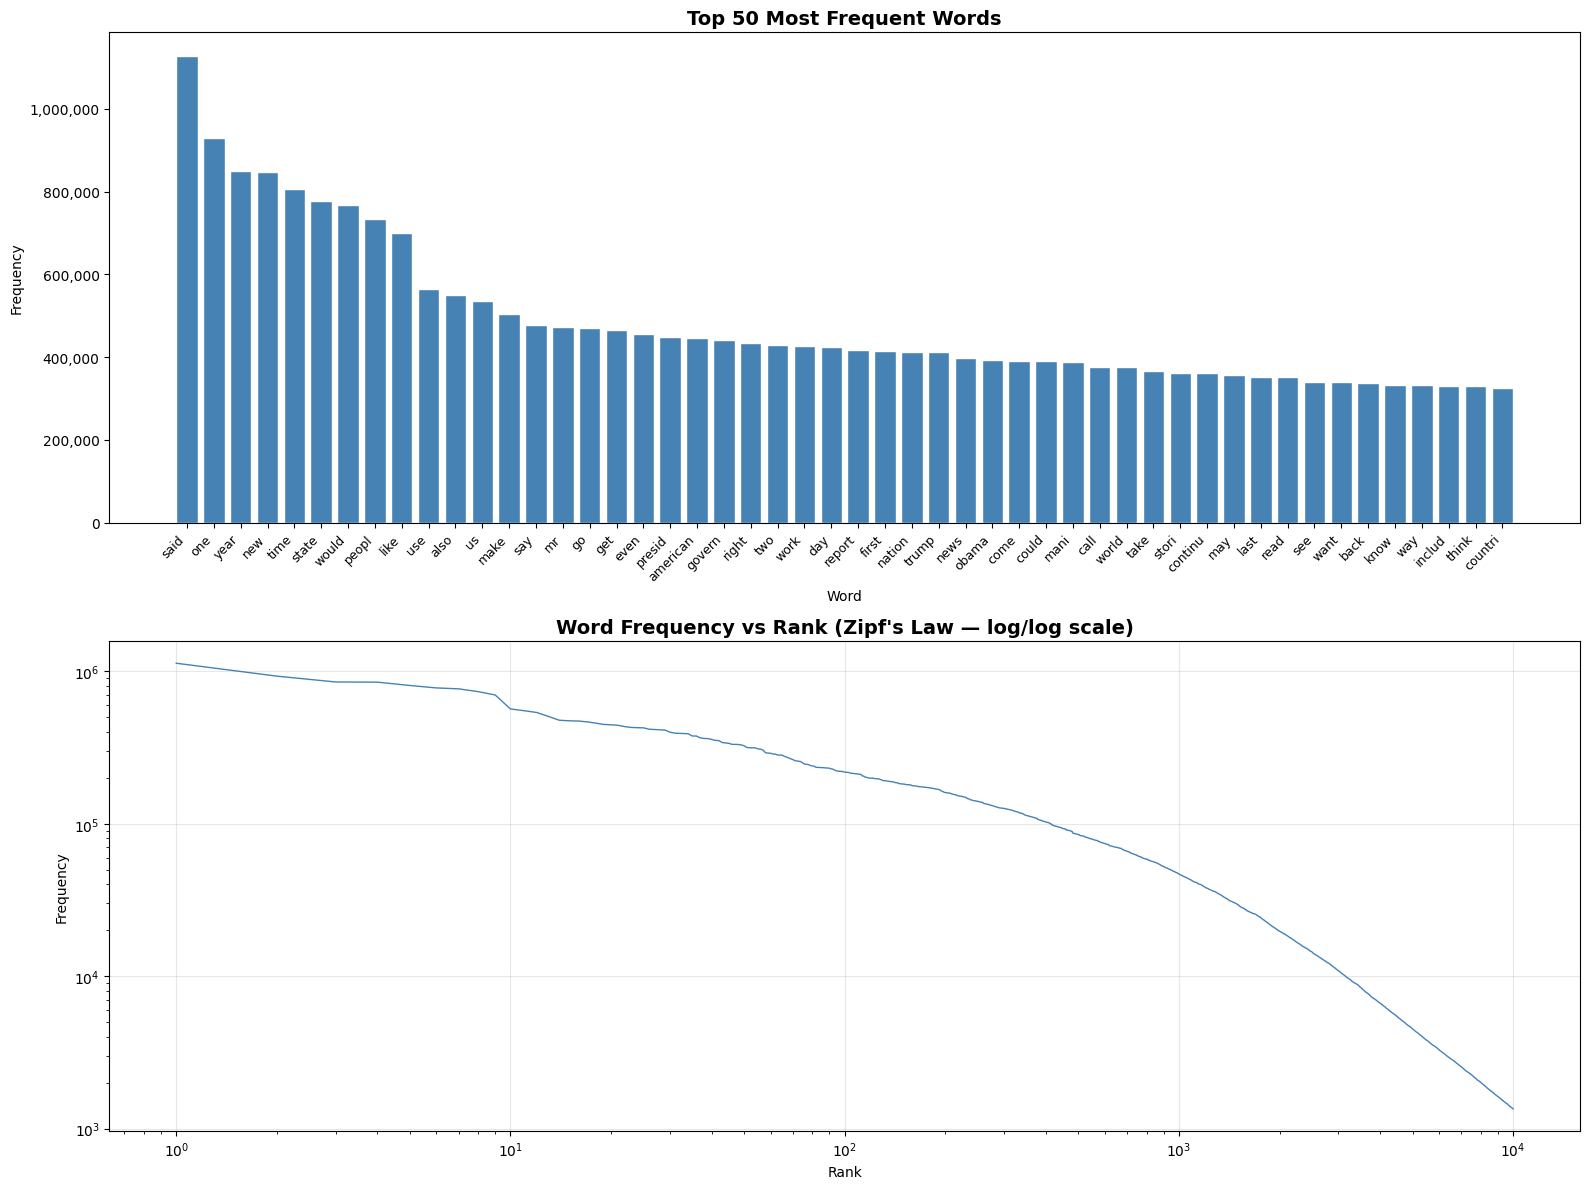


Top 10 words:
  said                  1,128,832
  one                     928,873
  year                    850,409
  new                     848,186
  time                    806,557
  state                   777,432
  would                   766,651
  peopl                   735,049
  like                    699,029
  use                     565,753


In [5]:
from collections import Counter
import matplotlib.pyplot as plt

def plot_word_distribution(train_df, column="tokens_stemmed", top_n=50):
    """
    Plot the distribution of the most common words in the training set.
    """

    # ── Count all tokens ──────────────────────────────────────────────────────
    print("Counting tokens...")
    all_tokens = [t for tokens in train_df[column] for t in tokens]
    counts     = Counter(all_tokens)
    top_words  = counts.most_common(top_n)
    words, freqs = zip(*top_words)

    # ── Plot 1: Bar chart of top N words ──────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    axes[0].bar(range(top_n), freqs, color="steelblue", edgecolor="white")
    axes[0].set_xticks(range(top_n))
    axes[0].set_xticklabels(words, rotation=45, ha="right", fontsize=9)
    axes[0].set_title(f"Top {top_n} Most Frequent Words", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Word")
    axes[0].set_ylabel("Frequency")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # ── Plot 2: Zipf's law — log/log frequency rank plot ─────────────────────
    all_freqs = sorted(counts.values(), reverse=True)[:10000]
    axes[1].plot(range(1, len(all_freqs) + 1), all_freqs, color="steelblue", linewidth=1)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_title("Word Frequency vs Rank (Zipf's Law — log/log scale)", 
                       fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Rank")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("word_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nTop 10 words:")
    for word, freq in top_words[:10]:
        print(f"  {word:<20} {freq:>10,}")

plot_word_distribution(train_df)